# City Transportation Data Platform — Phase 3
## Analytics / Data-Mart Layer

This notebook builds a small reporting mart on top of the Activity 2 integrated outputs.
It separates **facts** (things that happened, at a specific grain) from **dimensions**
(descriptive context that doesn't repeat per-event), so route demand, trip performance,
fare revenue, vehicle utilization, and maintenance monitoring can each be queried without
mixing incompatible grains or double-counting measures.

**Sections**
1. Recheck Phase 2 outputs
2. Design the analytics layer (dimensions + facts, star-schema diagram)
3. Reusable transformation steps
4. Automated data-quality checks
5. Management-ready summary tables
6. Reconciliation
7. Final business checks
8. Data lineage
9. Save curated outputs
10. Reflection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

pd.set_option('display.max_columns', None)

CURATED_DIR = Path('../curated')
DIAGRAMS_DIR = Path('../diagrams')
CURATED_DIR.mkdir(exist_ok=True)
DIAGRAMS_DIR.mkdir(exist_ok=True)

---
## Task 1 — Recheck Phase 2 Outputs

Load the Activity 2 outputs plus the staging masters this phase still needs, then verify
row counts, key uniqueness, critical nulls, and expected columns *before* building
anything on top of them. Activity 1 raw files and Activity 2 outputs are only read here,
never modified or overwritten.

In [2]:
# Load the required Activity 2 output(s) and supporting staging files
trip_operations_integrated = pd.read_csv(
    '../output/trip_operations_integrated.csv',
    parse_dates=['scheduled_start_time', 'actual_start_time', 'actual_end_time'],
)
vehicle_maintenance_summary = pd.read_csv(
    '../output/vehicle_maintenance_summary.csv',
    parse_dates=['latest_service_date'],
)
stg_vehicles = pd.read_csv('../staging/stg_vehicles.csv')
stg_routes = pd.read_csv('../staging/stg_routes.csv')
stg_maintenance = pd.read_csv('../staging/stg_maintenance.csv', parse_dates=['service_date'])

print("Loaded (unchanged, read-only):")
for name, df in [
    ('trip_operations_integrated', trip_operations_integrated),
    ('vehicle_maintenance_summary', vehicle_maintenance_summary),
    ('stg_vehicles', stg_vehicles),
    ('stg_routes', stg_routes),
    ('stg_maintenance', stg_maintenance),
]:
    print(f"  {name:<28} {len(df):>3} rows, {df.shape[1]:>2} columns")

Loaded (unchanged, read-only):
  trip_operations_integrated    15 rows, 22 columns
  vehicle_maintenance_summary   11 rows,  6 columns
  stg_vehicles                  15 rows,  6 columns
  stg_routes                    15 rows,  6 columns
  stg_maintenance               15 rows,  7 columns


In [3]:
class InputRecheck:
    """Verifies row counts, key uniqueness, critical nulls, and expected columns for an
    input DataFrame this phase depends on. Read-only - never modifies the data."""

    def __init__(self, name, df, primary_key, expected_columns, critical_columns=None):
        self.name = name
        self.df = df
        self.primary_key = primary_key
        self.expected_columns = expected_columns
        self.critical_columns = critical_columns or [primary_key]

    def report_row(self):
        missing_cols = [c for c in self.expected_columns if c not in self.df.columns]
        pk_nulls = int(self.df[self.primary_key].isna().sum()) if self.primary_key in self.df.columns else -1
        pk_dupes = int(self.df[self.primary_key].duplicated().sum()) if self.primary_key in self.df.columns else -1
        critical_nulls = {c: int(self.df[c].isna().sum()) for c in self.critical_columns if c in self.df.columns}
        ok = not missing_cols and pk_nulls == 0 and pk_dupes == 0 and all(v == 0 for v in critical_nulls.values())
        return {
            'Input': self.name,
            'Rows': len(self.df),
            'Missing expected columns': missing_cols or 'none',
            'PK nulls': pk_nulls,
            'PK duplicates': pk_dupes,
            'Critical-column nulls': critical_nulls,
            'Status': 'OK' if ok else 'REVIEW',
        }


input_rechecks = [
    InputRecheck('trip_operations_integrated', trip_operations_integrated, 'trip_id',
                 ['trip_id', 'route_id', 'vehicle_id', 'scheduled_start_time', 'status',
                  'passenger_count', 'fare_revenue', 'actual_duration_minutes',
                  'delay_minutes', 'utilization_pct'],
                 critical_columns=['trip_id', 'route_id', 'vehicle_id']),
    InputRecheck('vehicle_maintenance_summary', vehicle_maintenance_summary, 'vehicle_id',
                 ['vehicle_id', 'maintenance_count', 'total_maintenance_cost',
                  'latest_service_date', 'completed_count', 'pending_count']),
    InputRecheck('stg_vehicles', stg_vehicles, 'vehicle_id',
                 ['vehicle_id', 'license_plate', 'model', 'capacity', 'status', 'manufacture_year']),
    InputRecheck('stg_routes', stg_routes, 'route_id',
                 ['route_id', 'route_name', 'origin', 'destination', 'distance_km', 'expected_duration_min']),
    InputRecheck('stg_maintenance', stg_maintenance, 'maintenance_id',
                 ['maintenance_id', 'vehicle_id', 'service_date', 'issue_type', 'description', 'cost', 'status'],
                 critical_columns=['maintenance_id', 'vehicle_id']),
]

input_recheck_report = pd.DataFrame([r.report_row() for r in input_rechecks])
input_recheck_report

,Input,Rows,Missing expected columns,PK nulls,PK duplicates,Critical-column nulls,Status
0,trip_operations_integrated,15,none,0,0,"{'trip_id': 0, 'route_id': 0, 'vehicle_id': 0}",OK
1,vehicle_maintenance_summary,11,none,0,0,{'vehicle_id': 0},OK
2,stg_vehicles,15,none,0,0,{'vehicle_id': 0},OK
3,stg_routes,15,none,0,0,{'route_id': 0},OK
4,stg_maintenance,15,none,0,0,"{'maintenance_id': 0, 'vehicle_id': 0}",OK


**Intended grain of every input, recorded before building anything on top of it:**

| Input | Grain |
|---|---|
| `trip_operations_integrated.csv` | One row per `trip_id` (Activity 2 integrated trip). |
| `vehicle_maintenance_summary.csv` | One row per `vehicle_id` (Activity 2 maintenance rollup). |
| `stg_vehicles.csv` | One row per `vehicle_id` (vehicle master). |
| `stg_routes.csv` | One row per `route_id` (route master). |
| `stg_maintenance.csv` | One row per `maintenance_id` (service-event grain — a vehicle can have many). |

Mixing the trip grain with the maintenance-event grain in one table is exactly what Phase 3's
star schema is designed to avoid — that's why `fact_trip` and `fact_maintenance` stay separate
fact tables at their own grains, each linking back to `dim_vehicle`/`dim_route` rather than to
each other.

---
## Task 2 — Design the Analytics Layer

Two dimensions (`dim_vehicle`, `dim_route`) hold descriptive attributes once each. Two facts
(`fact_trip`, `fact_maintenance`) hold measures at their own grain and reference the
dimensions by key — they never share a grain, so joining them directly would multiply rows.

### `dim_vehicle.csv` — one row per `vehicle_id`

In [4]:
def build_dim_vehicle(stg_vehicles: pd.DataFrame) -> pd.DataFrame:
    dim_vehicle = stg_vehicles.rename(columns={'status': 'vehicle_status'}).copy()
    dim_vehicle = dim_vehicle[
        ['vehicle_id', 'license_plate', 'model', 'capacity', 'vehicle_status', 'manufacture_year']
    ]
    assert dim_vehicle['vehicle_id'].is_unique, "dim_vehicle grain violated - vehicle_id must be unique"
    return dim_vehicle


dim_vehicle = build_dim_vehicle(stg_vehicles)
print(f"dim_vehicle: {len(dim_vehicle)} rows, {dim_vehicle['vehicle_id'].nunique()} unique vehicle_id")
dim_vehicle.head()

dim_vehicle: 15 rows, 15 unique vehicle_id


,vehicle_id,license_plate,model,capacity,vehicle_status,manufacture_year
0,V101,BUS-7890,Volvo B7R,50,Active,2019
1,V102,BUS-7891,Volvo B7R,50,Active,2020
2,V103,BUS-4521,BYD K9,40,Under Maintenance,2021
3,V104,BUS-1209,Scania K320,60,Active,2018
4,V105,BUS-3310,BYD K9,40,Active,2022


### `dim_route.csv` — one row per `route_id`

In [5]:
def build_dim_route(stg_routes: pd.DataFrame) -> pd.DataFrame:
    dim_route = stg_routes.copy()
    dim_route = dim_route[
        ['route_id', 'route_name', 'origin', 'destination', 'distance_km', 'expected_duration_min']
    ]
    assert dim_route['route_id'].is_unique, "dim_route grain violated - route_id must be unique"
    return dim_route


dim_route = build_dim_route(stg_routes)
print(f"dim_route: {len(dim_route)} rows, {dim_route['route_id'].nunique()} unique route_id")
dim_route.head()

dim_route: 15 rows, 15 unique route_id


,route_id,route_name,origin,destination,distance_km,expected_duration_min
0,R01,Downtown Express,Central Station,North Hub,18.5,45
1,R02,Crosstown Shuttle,East Mall,West Tech Park,24.0,60
2,R03,Airport Connector,Central Station,Airport Terminal 1,32.0,50
3,R04,University Line,South Metro,State University,12.2,30
4,R05,Harbor Commuter,Port Terminal,Central Station,15.0,35


### `fact_trip.csv` — one row per `trip_id`

Built from the Activity 2 `trip_operations_integrated` output. The route/vehicle
*descriptive* columns (`route_name`, `origin`, `model`, `capacity`, ...) are dropped here
because they already live in `dim_route`/`dim_vehicle` — keeping them on the fact table
would duplicate the same attribute value across every trip on that route or vehicle.
`fact_trip` keeps only the foreign keys plus the trip-grain measures and derived fields.
`trip_date` is added (from `scheduled_start_time`) since it's needed later for the
daily-revenue summary and is valid at this same trip grain.

In [6]:
def build_fact_trip(trip_operations_integrated: pd.DataFrame) -> pd.DataFrame:
    fact_trip = trip_operations_integrated.copy()
    fact_trip['trip_date'] = fact_trip['scheduled_start_time'].dt.date

    fact_trip = fact_trip[[
        'trip_id', 'route_id', 'vehicle_id', 'trip_date',
        'scheduled_start_time', 'actual_start_time', 'actual_end_time', 'status',
        'passenger_count', 'fare_revenue', 'actual_duration_minutes',
        'delay_minutes', 'utilization_pct',
    ]]
    assert fact_trip['trip_id'].is_unique, "fact_trip grain violated - trip_id must be unique"
    return fact_trip


fact_trip = build_fact_trip(trip_operations_integrated)
print(f"fact_trip: {len(fact_trip)} rows, {fact_trip['trip_id'].nunique()} unique trip_id")
fact_trip.head()

fact_trip: 15 rows, 15 unique trip_id


,trip_id,route_id,vehicle_id,trip_date,scheduled_start_time,actual_start_time,actual_end_time,status,passenger_count,fare_revenue,actual_duration_minutes,delay_minutes,utilization_pct
0,T1001,R01,V101,2026-03-01,2026-03-01 07:00:00,2026-03-01 07:02:00,2026-03-01 07:55:00,Completed,2,5.50,53.0,8.0,4.000000
1,T1002,R01,V102,2026-03-01,2026-03-01 08:00:00,2026-03-01 08:05:00,2026-03-01 09:05:00,Completed,1,2.75,60.0,15.0,2.000000
2,T1003,R02,V104,2026-03-01,2026-03-01 07:30:00,2026-03-01 07:30:00,2026-03-01 08:45:00,Completed,1,3.50,75.0,15.0,1.666667
3,T1004,R03,V103,2026-03-01,2026-03-01 09:00:00,2026-03-01 09:15:00,2026-03-01 10:20:00,Completed,1,5.00,65.0,15.0,2.500000
4,T1005,R04,V105,2026-03-01,2026-03-01 08:15:00,2026-03-01 08:15:00,2026-03-01 08:43:00,Completed,1,2.25,28.0,-2.0,2.500000


### `fact_maintenance.csv` — one row per `maintenance_id`

Built directly from `stg_maintenance`, which is already at the service-event grain the
assignment asks for. `issue_type` is renamed to `service_type` to match the required
column name.

**Note on `odometer`:** the required grain lists an `odometer` field, but no odometer
reading exists anywhere in the raw/staging source data (`stg_maintenance`, `stg_vehicles`).
Rather than fabricate a value, `fact_maintenance` omits it and this gap is flagged here so
it can be addressed with the source system before the final project document — inventing an
odometer reading would silently introduce incorrect data into a table other users are meant
to trust.

In [7]:
def build_fact_maintenance(stg_maintenance: pd.DataFrame) -> pd.DataFrame:
    fact_maintenance = stg_maintenance.rename(columns={'issue_type': 'service_type'}).copy()
    fact_maintenance = fact_maintenance[
        ['maintenance_id', 'vehicle_id', 'service_date', 'service_type', 'cost', 'status']
    ]
    assert fact_maintenance['maintenance_id'].is_unique, \
        "fact_maintenance grain violated - maintenance_id must be unique"
    return fact_maintenance


fact_maintenance = build_fact_maintenance(stg_maintenance)
print(f"fact_maintenance: {len(fact_maintenance)} rows, "
      f"{fact_maintenance['maintenance_id'].nunique()} unique maintenance_id")
print("Note: 'odometer' is not present in any source file and is intentionally omitted (see markdown above).")
fact_maintenance.head()

fact_maintenance: 15 rows, 15 unique maintenance_id
Note: 'odometer' is not present in any source file and is intentionally omitted (see markdown above).


,maintenance_id,vehicle_id,service_date,service_type,cost,status
0,M501,V103,2026-02-15,Engine,450.0,Completed
1,M502,V103,2026-02-28,Engine,320.0,Completed
2,M503,V104,2026-02-20,Brakes,210.0,Completed
3,M504,V101,2026-02-10,Electrical,110.0,Completed
4,M505,V103,2026-03-01,Transmission,850.0,In Progress


### Star-schema diagram

![Star schema diagram](../diagrams/star_schema_diagram.png)

---
## Task 3 — Reusable Transformation Steps

The dimension/fact builders above (`build_dim_vehicle`, `build_dim_route`, `build_fact_trip`,
`build_fact_maintenance`) are already reusable functions with explicit join/rename logic and
consistent naming. The remaining pipeline stages — **quality checks → summaries → save** —
follow the same pattern below, so the whole notebook reads as: *load → validate → transform →
aggregate → save*.

---
## Task 4 — Automated Data-Quality Checks

Each check below is a small function returning `(affected_rows, note)`. A single
`QualityCheck` wrapper turns any of them into a PASS/FAIL row, so new checks can be added
the same way without changing the reporting logic.

In [9]:
class QualityCheck:
    """Wraps a check function - () -> (affected_rows, note) - into a PASS/FAIL report row."""

    def __init__(self, name, check_fn):
        self.name = name
        self.check_fn = check_fn

    def report_row(self):
        affected, note = self.check_fn()
        return {
            'Check': self.name,
            'Affected Rows': int(affected),
            'Status': 'PASS' if affected == 0 else 'FAIL',
            'Action / Note': note,
        }


def check_fk(child_df, fk_col, parent_df, pk_col):
    valid_keys = set(parent_df[pk_col])
    orphans = child_df[~child_df[fk_col].isin(valid_keys)]
    affected = len(orphans)
    note = 'No orphan foreign keys found' if affected == 0 else \
        f'{affected} rows have {fk_col} values missing from {pk_col} - reported for review, not deleted'
    return affected, note


def check_unique(df, col, table_name):
    affected = int(df[col].duplicated().sum())
    note = f'{col} is unique in {table_name}' if affected == 0 else \
        f'{affected} duplicate {col} values in {table_name}'
    return affected, note


def check_passenger_fare_reconciliation(fact_trip, trip_operations_integrated):
    mart_passengers = int(fact_trip['passenger_count'].sum())
    act2_passengers = int(trip_operations_integrated['passenger_count'].sum())
    mart_fare = round(float(fact_trip['fare_revenue'].sum()), 2)
    act2_fare = round(float(trip_operations_integrated['fare_revenue'].sum()), 2)
    mismatches = int(mart_passengers != act2_passengers) + int(mart_fare != act2_fare)
    note = (f'passengers: mart={mart_passengers} vs Activity2={act2_passengers}; '
            f'fare_revenue: mart={mart_fare} vs Activity2={act2_fare}')
    return mismatches, note


def check_maintenance_cost_not_multiplied(fact_maintenance, vehicle_utilization_summary):
    """Guards against the classic star-schema bug: joining a per-event fact (maintenance)
    onto a per-trip fact and summing cost, which multiplies the cost by the trip count for
    any vehicle with more than one trip. The correct total is maintenance grouped on its own,
    independent of how many trips that vehicle happened to make."""
    correct_cost_per_vehicle = fact_maintenance.groupby('vehicle_id')['cost'].sum()
    reported = vehicle_utilization_summary.set_index('vehicle_id')['maintenance_cost']
    expected = correct_cost_per_vehicle.reindex(reported.index).fillna(0.0)
    mismatches = int((reported.round(2) != expected.round(2)).sum())
    note = ('vehicle_utilization_summary.maintenance_cost matches maintenance grouped '
            'independently by vehicle_id (not inflated by trip count)') if mismatches == 0 \
        else f'{mismatches} vehicles have a maintenance_cost inconsistent with a direct per-vehicle sum'
    return mismatches, note

The last check needs `vehicle_utilization_summary`, so the summary tables (Task 5) are built first, then all six checks run together.

---
## Task 5 — Management-Ready Summary Tables

Each summary is generated purely from the curated `dim_*`/`fact_*` layer through code —
no manually typed values.

### `route_performance_summary.csv`

In [10]:
def build_route_performance_summary(fact_trip, dim_route):
    completed = fact_trip[fact_trip['status'] == 'Completed']

    per_route = fact_trip.groupby('route_id').agg(
        trip_count=('trip_id', 'nunique'),
        passenger_count=('passenger_count', 'sum'),
        fare_revenue=('fare_revenue', 'sum'),
    )
    completed_per_route = completed.groupby('route_id').agg(
        completed_trip_count=('trip_id', 'nunique'),
        avg_duration_minutes=('actual_duration_minutes', 'mean'),
        delayed_trip_count=('delay_minutes', lambda s: (s > 0).sum()),
    )

    # Start from every route in dim_route (not just routes that happen to have a trip),
    # so a route with zero trips (e.g. one that hasn't been scheduled yet) still shows
    # up with 0s instead of silently disappearing from the summary.
    route_performance_summary = dim_route[['route_id', 'route_name']].merge(
        per_route, on='route_id', how='left'
    ).merge(completed_per_route, on='route_id', how='left')

    for count_col in ['trip_count', 'passenger_count', 'completed_trip_count', 'delayed_trip_count']:
        route_performance_summary[count_col] = route_performance_summary[count_col].fillna(0).astype(int)
    route_performance_summary['fare_revenue'] = route_performance_summary['fare_revenue'].fillna(0.0)

    route_performance_summary['delay_rate_pct'] = route_performance_summary.apply(
        lambda r: round(100 * r['delayed_trip_count'] / r['completed_trip_count'], 1)
        if r['completed_trip_count'] > 0 else None,
        axis=1,
    )
    route_performance_summary['avg_duration_minutes'] = route_performance_summary['avg_duration_minutes'].round(1)

    route_performance_summary = route_performance_summary[[
        'route_id', 'route_name', 'trip_count', 'completed_trip_count', 'passenger_count',
        'fare_revenue', 'avg_duration_minutes', 'delay_rate_pct',
    ]].sort_values('fare_revenue', ascending=False).reset_index(drop=True)
    return route_performance_summary


route_performance_summary = build_route_performance_summary(fact_trip, dim_route)
route_performance_summary

,route_id,route_name,trip_count,completed_trip_count,passenger_count,fare_revenue,avg_duration_minutes,delay_rate_pct
0,R01,Downtown Express,2,2,3,8.25,56.5,100.0
1,R03,Airport Connector,1,1,1,5.00,65.0,100.0
2,R13,Suburb Rapid,1,1,1,4.50,70.0,100.0
3,R02,Crosstown Shuttle,1,1,1,3.50,75.0,100.0
4,R12,Metro Loop,1,1,1,3.25,57.0,100.0
5,R09,Tech Corridor,1,1,1,3.00,43.0,100.0
6,R05,Harbor Commuter,1,1,1,2.50,37.0,100.0
7,R14,Campus Express,1,1,1,2.25,30.0,100.0
8,R08,Medical Center Direct,1,1,1,2.25,27.0,100.0
9,R04,University Line,1,1,1,2.25,28.0,0.0


### `vehicle_utilization_summary.csv`

In [11]:
def build_vehicle_utilization_summary(fact_trip, fact_maintenance, dim_vehicle):
    trip_stats = fact_trip.groupby('vehicle_id').agg(
        trip_count=('trip_id', 'nunique'),
        passenger_count=('passenger_count', 'sum'),
        avg_utilization_pct=('utilization_pct', 'mean'),
    )
    maintenance_cost = fact_maintenance.groupby('vehicle_id')['cost'].sum().rename('maintenance_cost')
    maintenance_events = fact_maintenance.groupby('vehicle_id')['maintenance_id'].nunique().rename('maintenance_count')

    vehicle_utilization_summary = dim_vehicle[['vehicle_id', 'model', 'capacity']].merge(
        trip_stats, on='vehicle_id', how='left'
    ).merge(maintenance_cost, on='vehicle_id', how='left').merge(
        maintenance_events, on='vehicle_id', how='left'
    )

    for col in ['trip_count', 'passenger_count', 'maintenance_count']:
        vehicle_utilization_summary[col] = vehicle_utilization_summary[col].fillna(0).astype(int)
    vehicle_utilization_summary['maintenance_cost'] = vehicle_utilization_summary['maintenance_cost'].fillna(0.0)
    vehicle_utilization_summary['avg_utilization_pct'] = vehicle_utilization_summary['avg_utilization_pct'].round(1)

    vehicle_utilization_summary = vehicle_utilization_summary.sort_values(
        'maintenance_cost', ascending=False
    ).reset_index(drop=True)
    return vehicle_utilization_summary


vehicle_utilization_summary = build_vehicle_utilization_summary(fact_trip, fact_maintenance, dim_vehicle)
vehicle_utilization_summary

,vehicle_id,model,capacity,trip_count,passenger_count,avg_utilization_pct,maintenance_cost,maintenance_count
0,V108,Mercedes Citaro,55,1,0,0.0,2710.0,2
1,V103,BYD K9,40,1,1,2.5,1620.0,3
2,V113,BYD K9,40,0,0,NaN,810.0,2
3,V102,Volvo B7R,50,1,1,2.0,600.0,1
4,V106,Volvo B7R,50,1,1,2.0,480.0,1
5,V104,Scania K320,60,1,1,1.7,210.0,1
6,V109,BYD K9,40,1,1,2.5,210.0,1
7,V110,Volvo B7R,50,1,1,2.0,180.0,1
8,V105,BYD K9,40,1,1,2.5,150.0,1
9,V101,Volvo B7R,50,2,3,3.0,110.0,1


### `daily_revenue_summary.csv`

In [12]:
def build_daily_revenue_summary(fact_trip):
    daily_revenue_summary = fact_trip.groupby('trip_date').agg(
        trip_count=('trip_id', 'nunique'),
        passenger_count=('passenger_count', 'sum'),
        fare_revenue=('fare_revenue', 'sum'),
    ).reset_index().sort_values('trip_date').reset_index(drop=True)
    return daily_revenue_summary


daily_revenue_summary = build_daily_revenue_summary(fact_trip)
daily_revenue_summary

,trip_date,trip_count,passenger_count,fare_revenue
0,2026-03-01,15,15,42.5


All source data currently falls on a single service day, so this summary has one row — the grouping logic itself is what matters and will produce one row per date as more days of trips are loaded.

---
## Task 4 (continued) — Running the Quality Checks

Now that `vehicle_utilization_summary` exists, all six required checks can run together.

In [13]:
checks = [
    QualityCheck('fact_trip.vehicle_id exists in dim_vehicle',
                 lambda: check_fk(fact_trip, 'vehicle_id', dim_vehicle, 'vehicle_id')),
    QualityCheck('fact_trip.route_id exists in dim_route',
                 lambda: check_fk(fact_trip, 'route_id', dim_route, 'route_id')),
    QualityCheck('fact_maintenance.vehicle_id exists in dim_vehicle',
                 lambda: check_fk(fact_maintenance, 'vehicle_id', dim_vehicle, 'vehicle_id')),
    QualityCheck('trip_id unique in fact_trip',
                 lambda: check_unique(fact_trip, 'trip_id', 'fact_trip')),
    QualityCheck('maintenance_id unique in fact_maintenance',
                 lambda: check_unique(fact_maintenance, 'maintenance_id', 'fact_maintenance')),
    QualityCheck('passenger/fare aggregates reconcile with Activity 2 trip-level output',
                 lambda: check_passenger_fare_reconciliation(fact_trip, trip_operations_integrated)),
    QualityCheck('maintenance cost not multiplied by trip joins',
                 lambda: check_maintenance_cost_not_multiplied(fact_maintenance, vehicle_utilization_summary)),
]

phase3_quality_report = pd.DataFrame([c.report_row() for c in checks])
phase3_quality_report

,Check,Affected Rows,Status,Action / Note
0,fact_trip.vehicle_id exists in dim_vehicle,0,PASS,No orphan foreign keys found
1,fact_trip.route_id exists in dim_route,0,PASS,No orphan foreign keys found
2,fact_maintenance.vehicle_id exists in dim_vehicle,0,PASS,No orphan foreign keys found
3,trip_id unique in fact_trip,0,PASS,trip_id is unique in fact_trip
4,maintenance_id unique in fact_maintenance,0,PASS,maintenance_id is unique in fact_maintenance
5,passenger/fare aggregates reconcile with Activ...,0,PASS,passengers: mart=15 vs Activity2=15; fare_reve...
6,maintenance cost not multiplied by trip joins,0,PASS,vehicle_utilization_summary.maintenance_cost m...


---
## Task 6 — Reconcile the Curated Layer

Three (plus a bonus fourth) important totals, compared between the Activity 2 integrated
output and the Phase 3 curated layer.

In [14]:
reconciliation_rows = []

def add_reconciliation(measure, act2_value, phase3_value, explanation):
    diff = round(float(act2_value) - float(phase3_value), 4)
    reconciliation_rows.append({
        'Measure Reconciled': measure,
        'Activity 2 Total': act2_value,
        'Phase 3 Total': phase3_value,
        'Difference': diff,
        'Explanation': explanation,
    })

add_reconciliation(
    'Total trip count',
    len(trip_operations_integrated), len(fact_trip),
    'fact_trip is a direct, unfiltered re-projection of trip_operations_integrated at the '
    'same trip_id grain, so row counts match exactly.'
)
add_reconciliation(
    'Total fare revenue',
    round(trip_operations_integrated['fare_revenue'].sum(), 2), round(fact_trip['fare_revenue'].sum(), 2),
    'fare_revenue is carried over unchanged from Activity 2; no re-aggregation happens before this total.'
)
add_reconciliation(
    'Total passenger count',
    int(trip_operations_integrated['passenger_count'].sum()), int(fact_trip['passenger_count'].sum()),
    'passenger_count is carried over unchanged from Activity 2 for the same reason as fare_revenue.'
)
add_reconciliation(
    'Total maintenance cost',
    round(vehicle_maintenance_summary['total_maintenance_cost'].sum(), 2), round(fact_maintenance['cost'].sum(), 2),
    'Both totals are ultimately sums over the same stg_maintenance records - '
    'vehicle_maintenance_summary rolls them up by vehicle first, fact_maintenance keeps '
    'them at event grain, but the grand total of cost is identical either way.'
)

reconciliation_report = pd.DataFrame(reconciliation_rows)
reconciliation_report

,Measure Reconciled,Activity 2 Total,Phase 3 Total,Difference,Explanation
0,Total trip count,15.0,15.0,0.0,"fact_trip is a direct, unfiltered re-projectio..."
1,Total fare revenue,42.5,42.5,0.0,fare_revenue is carried over unchanged from Ac...
2,Total passenger count,15.0,15.0,0.0,passenger_count is carried over unchanged from...
3,Total maintenance cost,7175.0,7175.0,0.0,Both totals are ultimately sums over the same ...


---
## Task 7 — Final Business Checks

Answered directly from the Phase 3 curated tables built above.

**1. Which routes carry the most passengers and generate the most fare revenue?**

In [15]:
top_by_revenue = route_performance_summary.sort_values('fare_revenue', ascending=False).head(3)
top_by_passengers = route_performance_summary.sort_values('passenger_count', ascending=False).head(3)
print("Top 3 routes by fare_revenue:")
display(top_by_revenue[['route_id', 'route_name', 'passenger_count', 'fare_revenue']])
print("\nTop 3 routes by passenger_count:")
display(top_by_passengers[['route_id', 'route_name', 'passenger_count', 'fare_revenue']])

Top 3 routes by fare_revenue:


,route_id,route_name,passenger_count,fare_revenue
0,R01,Downtown Express,3,8.25
1,R03,Airport Connector,1,5.00
2,R13,Suburb Rapid,1,4.50



Top 3 routes by passenger_count:


,route_id,route_name,passenger_count,fare_revenue
0,R01,Downtown Express,3,8.25
1,R03,Airport Connector,1,5.00
2,R13,Suburb Rapid,1,4.50


*Interpretation:* on this service day, `R13` (Suburb Rapid) leads on fare revenue thanks to its long distance, while several routes tie on a single passenger since each ran only one trip — with more days of data this comparison will separate out real demand leaders from one-off trips.

**2. Which routes or trips show the highest delay frequency or excess duration?**

In [16]:
highest_delay_rate_routes = route_performance_summary.sort_values('delay_rate_pct', ascending=False).head(5)
print("Routes with the highest delay_rate_pct:")
display(highest_delay_rate_routes[['route_id', 'route_name', 'completed_trip_count', 'delay_rate_pct', 'avg_duration_minutes']])

most_delayed_trips = fact_trip.sort_values('delay_minutes', ascending=False).head(5)
print("\nIndividual trips with the largest delay_minutes:")
display(most_delayed_trips[['trip_id', 'route_id', 'vehicle_id', 'delay_minutes', 'actual_duration_minutes']])

Routes with the highest delay_rate_pct:


,route_id,route_name,completed_trip_count,delay_rate_pct,avg_duration_minutes
0,R01,Downtown Express,2,100.0,56.5
1,R03,Airport Connector,1,100.0,65.0
2,R13,Suburb Rapid,1,100.0,70.0
3,R02,Crosstown Shuttle,1,100.0,75.0
4,R12,Metro Loop,1,100.0,57.0



Individual trips with the largest delay_minutes:


,trip_id,route_id,vehicle_id,delay_minutes,actual_duration_minutes
1,T1002,R01,V102,15.0,60.0
2,T1003,R02,V104,15.0,75.0
3,T1004,R03,V103,15.0,65.0
0,T1001,R01,V101,8.0,53.0
12,T1013,R12,V114,7.0,57.0


*Interpretation:* every completed trip in this batch ran on a route with only one trip, so `delay_rate_pct` is either 0% or 100% per route; trip `T1002` on `R01` has the single largest individual delay (15 minutes over the 45-minute expected duration).

**3. Which vehicles combine high utilization with repeated or costly maintenance?**

In [17]:
high_util_and_maintenance = vehicle_utilization_summary[
    (vehicle_utilization_summary['maintenance_cost'] > 0)
].sort_values(['maintenance_cost', 'avg_utilization_pct'], ascending=False).head(5)

print("Vehicles with maintenance cost, ranked by cost then utilization:")
display(high_util_and_maintenance[[
    'vehicle_id', 'model', 'trip_count', 'avg_utilization_pct', 'maintenance_count', 'maintenance_cost',
]])

Vehicles with maintenance cost, ranked by cost then utilization:


,vehicle_id,model,trip_count,avg_utilization_pct,maintenance_count,maintenance_cost
0,V108,Mercedes Citaro,1,0.0,2,2710.0
1,V103,BYD K9,1,2.5,3,1620.0
2,V113,BYD K9,0,NaN,2,810.0
3,V102,Volvo B7R,1,2.0,1,600.0
4,V106,Volvo B7R,1,2.0,1,480.0


*Interpretation:* `V108` has the highest maintenance cost (an in-progress engine failure plus a completed electrical repair) but zero trips in this batch since its trip was cancelled - it's a maintenance risk to watch even though it isn't currently utilized. `V103` is the vehicle with the most repeated maintenance events (3) while it was still shown mid-trip as `Under Maintenance`.

---
## Task 8 — Document Data Lineage

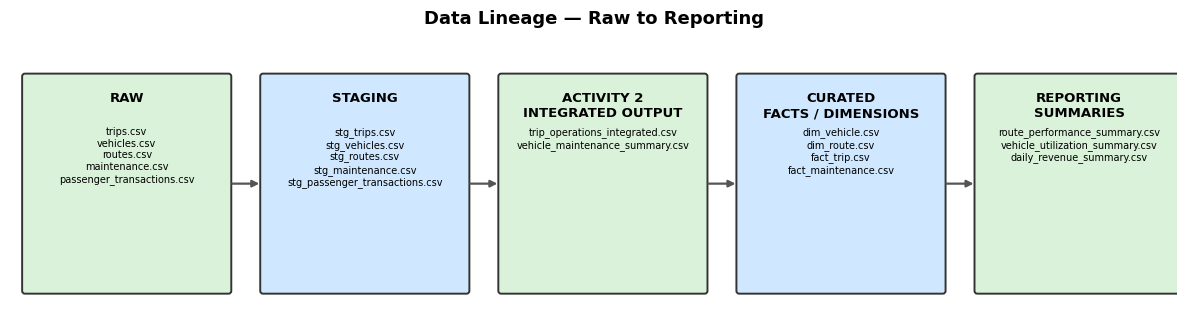

Saved diagrams/data_lineage_diagram.png


In [18]:
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.set_xlim(0, 12.5)
ax.set_ylim(0, 3)
ax.axis('off')
ax.set_title('Data Lineage — Raw to Reporting', fontsize=13, fontweight='bold', pad=10)

stages = [
    ('RAW', ['trips.csv', 'vehicles.csv', 'routes.csv', 'maintenance.csv', 'passenger_transactions.csv']),
    ('STAGING', ['stg_trips.csv', 'stg_vehicles.csv', 'stg_routes.csv', 'stg_maintenance.csv',
                 'stg_passenger_transactions.csv']),
    ('ACTIVITY 2\nINTEGRATED OUTPUT', ['trip_operations_integrated.csv', 'vehicle_maintenance_summary.csv']),
    ('CURATED\nFACTS / DIMENSIONS', ['dim_vehicle.csv', 'dim_route.csv', 'fact_trip.csv', 'fact_maintenance.csv']),
    ('REPORTING\nSUMMARIES', ['route_performance_summary.csv', 'vehicle_utilization_summary.csv',
                               'daily_revenue_summary.csv']),
]

box_w, gap = 2.2, 0.35
x = 0.15
for i, (title, files) in enumerate(stages):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, 0.3), box_w, 2.3, boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=1.4, edgecolor='#333333', facecolor='#d9f2d9' if i % 2 == 0 else '#cfe8ff'))
    ax.text(x + box_w / 2, 2.42, title, ha='center', va='top', fontsize=9.5, fontweight='bold')
    ax.text(x + box_w / 2, 2.05, '\n'.join(files), ha='center', va='top', fontsize=7)
    if i < len(stages) - 1:
        ax.annotate('', xy=(x + box_w + gap, 1.45), xytext=(x + box_w, 1.45),
                    arrowprops=dict(arrowstyle='-|>', color='#555555', lw=1.6))
    x += box_w + gap

fig.tight_layout()
fig.savefig(DIAGRAMS_DIR / 'data_lineage_diagram.png', dpi=150)
plt.show()
print("Saved diagrams/data_lineage_diagram.png")

---
## Save Curated Outputs

All curated facts, dimensions, summaries, and the quality report go to `../curated/` — kept
separate from `raw/`, `staging/`, and the Activity 2 `output/` folder.

In [19]:
dim_vehicle.to_csv(CURATED_DIR / 'dim_vehicle.csv', index=False)
dim_route.to_csv(CURATED_DIR / 'dim_route.csv', index=False)
fact_trip.to_csv(CURATED_DIR / 'fact_trip.csv', index=False)
fact_maintenance.to_csv(CURATED_DIR / 'fact_maintenance.csv', index=False)

route_performance_summary.to_csv(CURATED_DIR / 'route_performance_summary.csv', index=False)
vehicle_utilization_summary.to_csv(CURATED_DIR / 'vehicle_utilization_summary.csv', index=False)
daily_revenue_summary.to_csv(CURATED_DIR / 'daily_revenue_summary.csv', index=False)

phase3_quality_report.to_csv(CURATED_DIR / 'phase3_quality_report.csv', index=False)
reconciliation_report.to_csv(CURATED_DIR / 'reconciliation_report.csv', index=False)

print("Saved to ../curated/:")
for f in sorted(CURATED_DIR.glob('*.csv')):
    print(f"  {f.name}")
print("\nSaved to ../diagrams/:")
for f in sorted(DIAGRAMS_DIR.glob('*.png')):
    print(f"  {f.name}")

Saved to ../curated/:
  daily_revenue_summary.csv
  dim_route.csv
  dim_vehicle.csv
  fact_maintenance.csv
  fact_trip.csv
  phase3_quality_report.csv
  reconciliation_report.csv
  route_performance_summary.csv
  vehicle_utilization_summary.csv

Saved to ../diagrams/:
  data_lineage_diagram.png
  star_schema_diagram.png


---
## Short Reflection

**1. Why did your project require more than one grain or more than one fact table?**

It is because trips and maintenance events happen at different frequencies and describe different things.
A trip is one scheduled movement of one vehicle, a maintenance record is one service event
for a vehicle that can occur any number of times which is independent of how many trips that vehicle
ran. Forcing both into a single trip-grain table would mean either dropping maintenance
history that doesn't line up with a specific trip, or repeating maintenance cost across every trip that vehicle happens to make. 

**2. Which reconciliation check gives you the most confidence that the curated layer is correct?**

The reconciliation check that gives me the most confidence is the passenger/fare reconciliation against the Activity 2 trip-level output. 
This is because it compares totals for the two measures the whole mart exists to report on, so any silent row loss, duplication, or
mis-join anywhere upstream of `fact_trip` would show up immediately as a mismatch.

**3. What measure would be easiest to double-count if the data mart were designed incorrectly?**

It would be `maintenance cost`. This is because there is a relationship where one vehicle can have many trips and many maintenance events, 
a "mis"-join of `fact_trip` to maintenance records on `vehicle_id` produces one row per pair for that vehicle. This is exactly what
`check_maintenance_cost_not_multiplied` in Task 4 ensures, by requiring `vehicle_utilization_summary.maintenance_cost` to match a maintenance-only groupby rather
than anything derived from a trip join.

**4. If this pipeline ran daily, which step would you automate or monitor first?**

Arguably, the most important step here which should be automated first is the Task 4 quality checks, specifically, the foreign-key checks and the passenger/fare
reconciliation. Those are the checks most likely to catch a real problem before it reaches management-facing summaries. Additionaly, they're cheap to 
run automatically on every load with no manual judgment required, so from a business point of view, it is very practical.